In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\\Users\\GMB\\Desktop\\Data\\Unemployment in India.csv")

In [9]:
df.head()
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [10]:
# Remove extra spaces in column names
df.columns = df.columns.str.strip()

# Check missing values
df.isnull().sum()

# Drop missing values
df = df.dropna()

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Extract Month & Year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

C:\Users\GMB\AppData\Local\Temp\ipykernel_7808\1988122067.py:11: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [11]:
# Average unemployment rate by region/state
state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values()

state_avg

Region
Meghalaya            4.798889
Odisha               5.657857
Assam                6.428077
Uttarakhand          6.582963
Gujarat              6.663929
Karnataka            6.676071
Sikkim               7.249412
Madhya Pradesh       7.406429
Andhra Pradesh       7.477143
Maharashtra          7.557500
Telangana            7.737857
West Bengal          8.124643
Chhattisgarh         9.240357
Goa                  9.274167
Tamil Nadu           9.284286
Kerala              10.123929
Puducherry          10.215000
Punjab              12.031071
Uttar Pradesh       12.551429
Rajasthan           14.058214
Chandigarh          15.991667
Jammu & Kashmir     16.188571
Delhi               16.495357
Himachal Pradesh    18.540357
Bihar               18.918214
Jharkhand           20.585000
Haryana             26.283214
Tripura             28.350357
Name: Estimated Unemployment Rate (%), dtype: float64

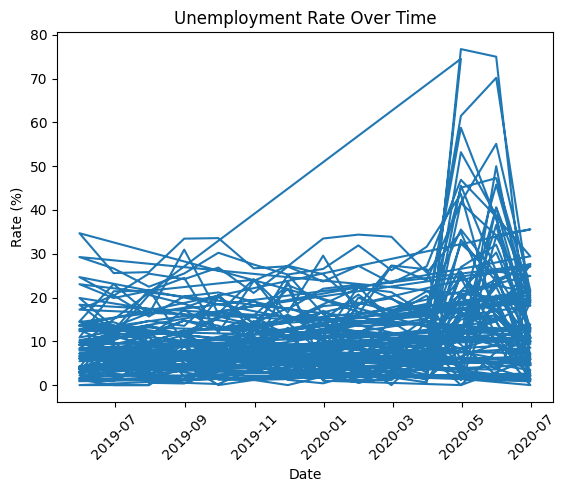

In [12]:
plt.figure()
plt.plot(df['Date'], df['Estimated Unemployment Rate (%)'])
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.xticks(rotation=45)
plt.show()

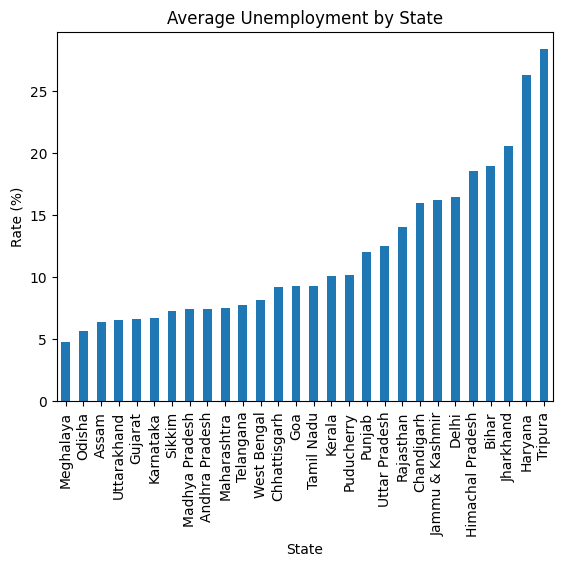

In [13]:
plt.figure()
state_avg.plot(kind='bar')
plt.title("Average Unemployment by State")
plt.xlabel("State")
plt.ylabel("Rate (%)")
plt.xticks(rotation=90)
plt.show()

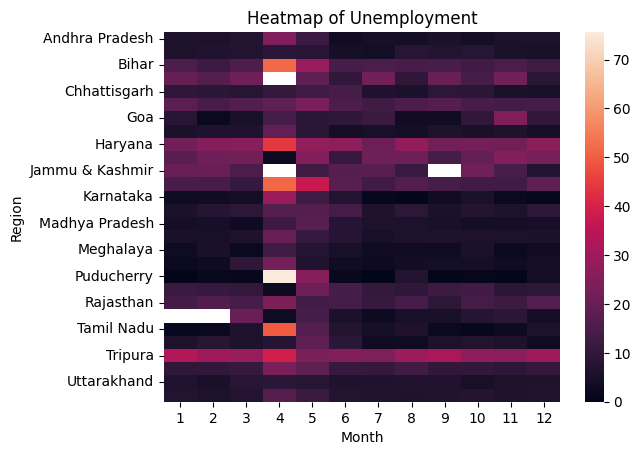

In [14]:
pivot = df.pivot_table(values='Estimated Unemployment Rate (%)',
                       index='Region',
                       columns='Month')

plt.figure()
sns.heatmap(pivot)
plt.title("Heatmap of Unemployment")
plt.show()

In [15]:
# Before COVID (2019)
before_covid = df[df['Year'] == 2019]['Estimated Unemployment Rate (%)'].mean()

# During COVID (2020)
during_covid = df[df['Year'] == 2020]['Estimated Unemployment Rate (%)'].mean()

print("Before COVID:", before_covid)
print("During COVID:", during_covid)

Before COVID: 9.399046511627906
During COVID: 15.10158064516129


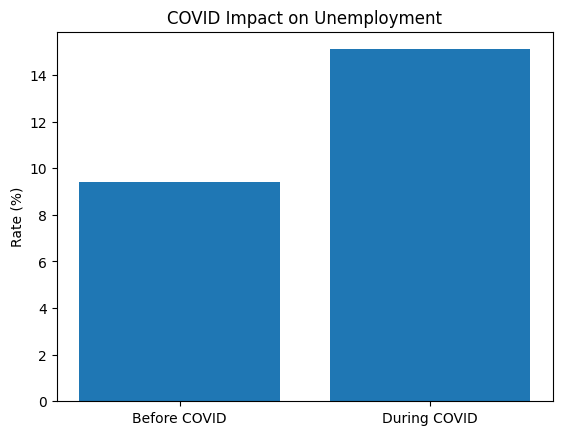

In [16]:
plt.figure()
plt.bar(['Before COVID', 'During COVID'], [before_covid, during_covid])
plt.title("COVID Impact on Unemployment")
plt.ylabel("Rate (%)")
plt.show()

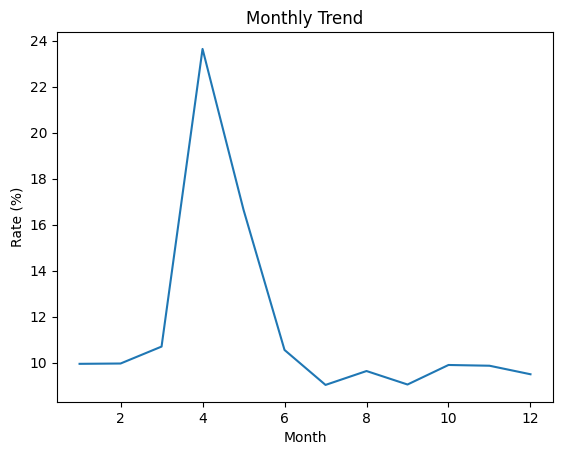

In [17]:
monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure()
monthly_avg.plot()
plt.title("Monthly Trend")
plt.xlabel("Month")
plt.ylabel("Rate (%)")
plt.show()

In [18]:
print("Highest unemployment state:", state_avg.idxmax())
print("Lowest unemployment state:", state_avg.idxmin())

if during_covid > before_covid:
    print("Unemployment increased during COVID-19")
else:
    print("Unemployment decreased during COVID-19")

print("Seasonal variation observed across months")

Highest unemployment state: Tripura
Lowest unemployment state: Meghalaya
Unemployment increased during COVID-19
Seasonal variation observed across months
